In [110]:
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,TargetEncoder, LabelEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score
from scipy.stats import loguniform
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingRegressor, BaggingClassifier
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import precision_score, root_mean_squared_error, ConfusionMatrixDisplay,classification_report, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier


<h3> preparacion de datos </h3>

In [2]:
#ROOT_DIR = Path().resolve().parent.parent
#DATA_DIR = ROOT_DIR / "data/raw"
#file_path = 'Telco_customer_churn.csv'

#Leer el archivo csv con pandas
#df = pd.read_csv(DATA_DIR / file_path, header=0, na_values=[' '])
df = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
#Mostrar las 5 primeras filas del dataframe
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [70]:
from sklearn.model_selection import train_test_split

X = df.drop(['capital-gain','income'], axis=1)
X.columns = X.columns.str.strip()

y = df['income']
#primero siempre se dividen los datos en entrenamiento y prueba, luego se hace el preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
    TargetEncoder
)

ss = StandardScaler() 
pt = PowerTransformer()
orden_education = [' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th', ' 11th', ' 12th',
         ' HS-grad',' Some-college', ' Assoc-acdm', ' Assoc-voc', ' Bachelors', ' Masters',
         ' Prof-school', ' Doctorate']

ore_education = OrdinalEncoder(categories=[orden_education], dtype='int', max_categories=6) # aqui reducimos a solo 6 categorias las de alta cardinalidad ordinales

ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore') 
oheAC = OneHotEncoder(sparse_output=False, drop='first', max_categories=6, handle_unknown='ignore') 

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (22792, 13)
Tamaño del conjunto de prueba es: (9769, 13)


In [71]:
#Aqui se define el preprocesador completo, indicando qué preprocesador se aplicará a cada variable. 
# Las demás columnas se descartan con remainder='drop'

preprocessor = ColumnTransformer(transformers=[
    ('power_transformer', pt, ['hours-per-week']),
    ('od_education_ac', ore_education, ['education']),
    ('std_one_hot_encoder', ohe, ['race','sex','workclass', 'relationship','marital-status']),
    ('one_hot_encoder_ac', oheAC, ['occupation', 'native-country'])
    ], remainder='drop') # Las demás columnas se descartan

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transformer', ...), ('od_education_ac', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transfor

<h2> Modelos de arboles de decision: clasificacion y regresion </h2>

In [72]:
pipelineTreeC = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=1))
])

# para un arbol de regresion se usa DecisionTreeRegressor(random_state=1)
"""
Si el arbol es de regresion se debe medir con estas metricas:
print(f'Best RMSE: {-grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train RMSE: {-grid_search.score(X_train, y_train):.2f}')
print(f'Test RMSE: {-grid_search.score(X_test, y_test):.2f}')
"""


pipelineTreeC.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","[' <=50K',' >50K']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transformer', ...), ('od_education_ac', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'

In [19]:
print(classification_report(y_test, pipelineTreeC.predict(X_test)))

              precision    recall  f1-score   support

       <=50K       0.86      0.89      0.88      7550
        >50K       0.58      0.53      0.55      2219

    accuracy                           0.81      9769
   macro avg       0.72      0.71      0.72      9769
weighted avg       0.80      0.81      0.80      9769



/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


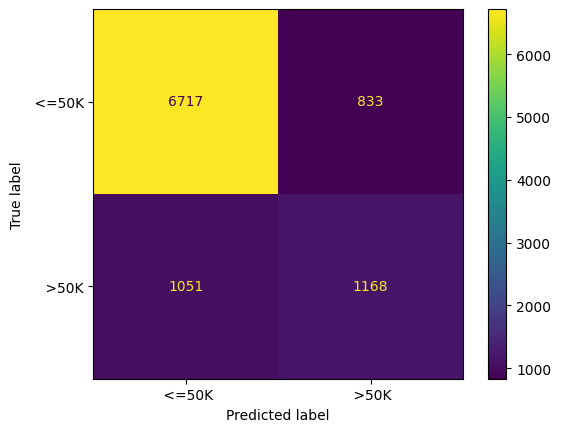

In [20]:
ConfusionMatrixDisplay.from_estimator(pipelineTreeC, X_test, y_test);

In [41]:
#importancia relativa
feature_names = (
    pipelineTreeC
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = pd.Series(
    pipelineTreeC.named_steps['model'].feature_importances_,
    index=feature_names
)

importances.sort_values(ascending=False)

std_one_hot_encoder__marital-status_ Married-civ-spouse       0.320349
power_transformer__hours-per-week                             0.164495
od_education_ac__education                                    0.114534
one_hot_encoder_ac__occupation_infrequent_sklearn             0.073064
one_hot_encoder_ac__occupation_ Craft-repair                  0.041076
std_one_hot_encoder__workclass_ Private                       0.019950
one_hot_encoder_ac__occupation_ Prof-specialty                0.019202
std_one_hot_encoder__race_ White                              0.017932
std_one_hot_encoder__sex_ Male                                0.016997
one_hot_encoder_ac__occupation_ Exec-managerial               0.016994
one_hot_encoder_ac__native-country_ United-States             0.016609
std_one_hot_encoder__workclass_ Self-emp-not-inc              0.015879
one_hot_encoder_ac__occupation_ Sales                         0.014283
one_hot_encoder_ac__native-country_infrequent_sklearn         0.013396
std_on

<h3> Sintonizacion de arboles </h3>

In [50]:
le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.fit_transform(y_test) # porque se requiere para grid search que sea un valor numerico

grid = {'model__ccp_alpha':np.logspace(-3, 3,25),
        'model__max_depth': [2,3,4,5],
        'model__min_samples_leaf':[3,5,7]
        }

""" si se decide usar GridSearchVC entonces el dict grid debe pasarse a param_grid en vez de param_distributions y ya no hay n_iter
grid_search = RandomizedSearchCV( 
    estimator=pipelineTreeC,
    param_distributions=grid,
    scoring='recall',
    n_iter=30)"""

grid_search = RandomizedSearchCV( 
    estimator=pipelineTreeC,
    param_distributions=grid,
    scoring='recall',
    n_iter=20
    )

grid_search.fit(X_train, y_train_le)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__ccp_alpha': array([1.0000...00000000e+03]), 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [3, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acr

In [51]:
print('Best CV f1 score is {:.3f} with params {}'.format(grid_search.best_score_, grid_search.best_params_))

Best CV f1 score is 0.675 with params {'model__min_samples_leaf': 7, 'model__max_depth': 2, 'model__ccp_alpha': np.float64(0.01)}


<h2> Modelos de Bagging y Random forest </h2>

Modelo de bagging

In [77]:
""" aqui es importante que el tipo de bagging cocuerde con el tipo de arbol, ambos de clasificacion o regresion"""

preprocessor.fit(X_train) # El modelo de Bagging rompe el preprocessor del pipeline, por eso procesamos los datos antes de, ya que este arbol no recive str
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=20,
    random_state=1
    )

bag_model.fit(X_train_prep, y_train_le)

train_score = root_mean_squared_error(y_train_le, bag_model.predict(X_train_prep))
test_score = root_mean_squared_error(y_test_le, bag_model.predict(X_test_prep))
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Train score: 0.329
Test score: 0.429


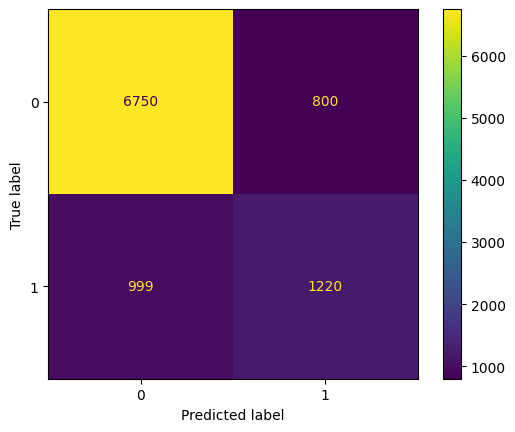

In [84]:
ConfusionMatrixDisplay.from_estimator(bag_model, X_test_prep, y_test_le);

Sintonizacion de modelo de bagging

In [87]:
grid = {
    'n_estimators':range(1, 201),
    'estimator__max_depth': [2,3,4,5],
    'estimator__min_samples_leaf':[3,5,7],
    'estimator__ccp_alpha':np.logspace(-3, 3,25)
}

search = RandomizedSearchCV(
    estimator=bag_model,
    param_distributions=grid,
    n_iter=10,
    scoring='recall',
    random_state=1
)

search.fit(X_train_prep, y_train_le)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...andom_state=1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__ccp_alpha': array([1.0000...00000000e+03]), 'estimator__max_depth': [2, 3, ...], 'estimator__min_samples_leaf': [3, 5, ...], 'n_estimators': range(1, 201)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratif

In [88]:
train_score = root_mean_squared_error(y_train_le, search.best_estimator_.predict(X_train_prep))
test_score = root_mean_squared_error(y_test_le, search.best_estimator_.predict(X_test_prep))
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.465
Test score: 0.468


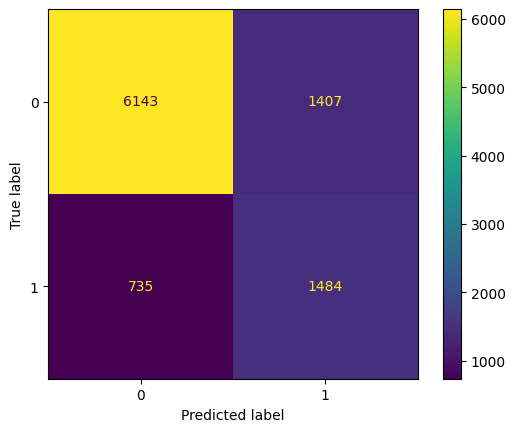

In [89]:
ConfusionMatrixDisplay.from_estimator(search.best_estimator_, X_test_prep, y_test_le);

<h3> Random Forest </h3>

In [95]:
pipelineRandomFC = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=20, random_state=1))
])


pipelineRandomFC.fit(X_train, y_train_le)

train_score = root_mean_squared_error(y_train_le, pipelineRandomFC.predict(X_train))
test_score = root_mean_squared_error(y_test_le, pipelineRandomFC.predict(X_test))
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.329
Test score: 0.426


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


sintonizacion de random forest

In [103]:
dist = {
    'model__n_estimators':range(1, 50),
    'model__ccp_alpha':np.logspace(-3, 3,25),
    'model__max_features':[4,5,6]
    }

search = RandomizedSearchCV(
    estimator=pipelineRandomFC,
    param_distributions=dist,
    random_state=1,
    scoring='f1',
    n_iter=20
    )

search.fit(X_train, y_train_le)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__ccp_alpha': array([1.0000...00000000e+03]), 'model__max_features': [4, 5, ...], 'model__n_estimators': range(1, 50)}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable 

In [ ]:
print(f'Train score: {search.best_estimator_.score(X_train, y_train_le):.3f}')
print(f'Test score: {search.best_estimator_.score(X_test, y_test_le):.3f}')

Train score: 0.822
Test score: 0.831


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [102]:
from sklearn.metrics import classification_report
print(classification_report(y_test_le, search.best_estimator_.predict(X_test)));

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      7550
           1       0.69      0.47      0.56      2219

    accuracy                           0.83      9769
   macro avg       0.77      0.70      0.73      9769
weighted avg       0.82      0.83      0.82      9769



/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


<h2> Modelos de Boosting </h2>

modelo ADA boost

In [105]:
ada = AdaBoostClassifier(
    n_estimators=50,
    random_state=1,
    )

ada_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', ada)
])

ada_model.fit(X_train, y_train)

train_score = f1_score(y_train, ada_model.predict(X_train), average='weighted')
test_score = f1_score(y_test, ada_model.predict(X_test), average='weighted')
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.810
Test score: 0.817


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


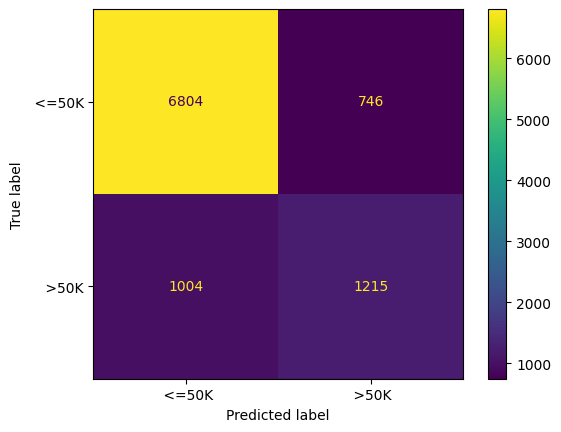

In [106]:
ConfusionMatrixDisplay.from_estimator(ada_model, X_test, y_test, display_labels=le.classes_);

sintonizacion del ada boost


In [108]:
dist = {
    'classifier__learning_rate':loguniform(1e-3, 10),
    'classifier__n_estimators': range(1, 50)}


random_search = RandomizedSearchCV(
    estimator=ada_model,
    param_distributions=dist,
    scoring='f1_weighted',
    n_iter=20,
    random_state=1
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.812 with parameters: {'classifier__learning_rate': np.float64(1.6256611075126237), 'classifier__n_estimators': 62}
Train score: 0.813
Test score: 0.824


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


modelo Gradient Boosting

In [111]:
gb = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=1)

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gb)
])

gb_model.fit(X_train, y_train)

train_score = f1_score(y_train, gb_model.predict(X_train), average='weighted')
test_score = f1_score(y_test, gb_model.predict(X_test), average='weighted')
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.815
Test score: 0.828


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


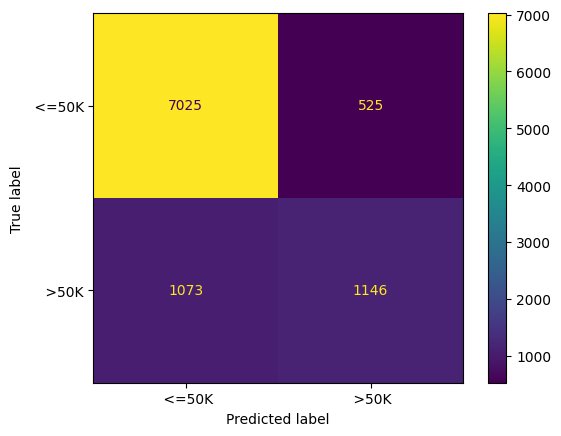

In [112]:
ConfusionMatrixDisplay.from_estimator(
    gb_model,
    X_test,
    y_test,
    display_labels=le.classes_
    );

sintonizacion de gradient boosting

In [113]:
dist = {
    'classifier__n_estimators':range(1, 100),
    'classifier__learning_rate':loguniform(1e-3,10),
    'classifier__min_samples_split':range(2,10)
    }

random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=dist,
    random_state=1,
    scoring='f1_weighted',
    n_iter=20
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.818 with parameters: {'classifier__learning_rate': np.float64(0.5571905096939267), 'classifier__min_samples_split': 6, 'classifier__n_estimators': 81}
Train score: 0.831
Test score: 0.831


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
